### Till Now 

All the steps we have taken till now are in one or the other way focused on reducing memory requirement for the training at various possible steps. Here’s a list of the most relevant techniques and methods to shrink the memory footprint of our
training loop:
1. Quantization of the base model 
2. Low-rank adaptation 
3. Quantization of the optimizer (8-bit optimizer)
4. Gradient accumulation
5. Gradient checkpointing
6. Memory efficient implementation of attention (Flash Attn/Pytorch SPDA) (less than quadratic memory) 

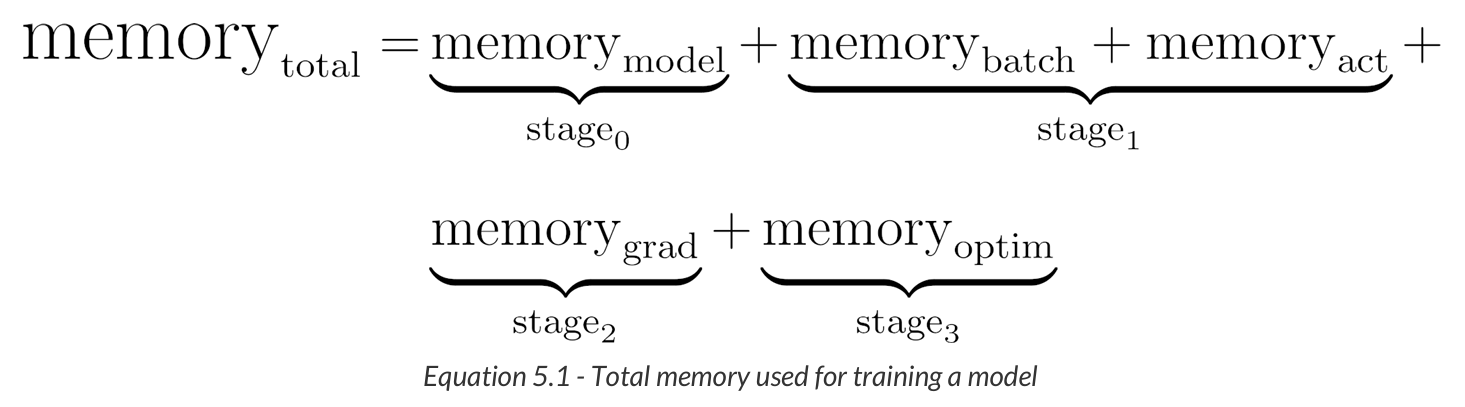

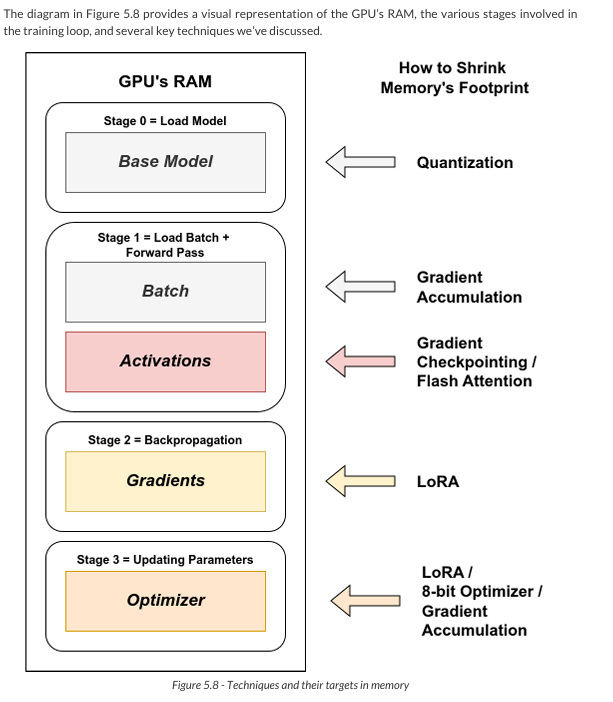

ref: A Hands-On Guide to Fine-Tuning LLMs by Daniel v. Godoy

---


We are familiar with the first three, lets look at the last two techniques.

**Gradient Accumulation** and **Gradient Checkpointing** are two of the most important memory-optimization tricks used when training (or fine-tuning) LLMs. They solve different problems but are often used together. 

### 1. Gradient Accumulation  
**What it is**  
Instead of updating the model weights after every single batch (which would require a huge batch size to fit in GPU memory), you compute gradients for several small batches, **add them up**, and only then perform one optimizer step.

It’s like “saving up” gradients over multiple forward+backward passes before actually stepping the optimizer.

**Why it helps with memory**  
- You can use a **tiny per-GPU batch size** (e.g., 1 or 2) that easily fits in VRAM.  
- The **effective batch size** becomes `per_device_batch_size × gradient_accumulation_steps`.  
- Memory usage during training is dominated by the **activations of one small batch** + the model weights + optimizer states.  
- You never have to hold the activations of a huge batch in memory at once.

**Simple formula**  
Effective batch size = `batch_size_per_device` × `gradient_accumulation_steps`

**How it works step-by-step (in one training iteration)**  
1. Forward pass on batch 1 → compute loss → backward pass → **accumulate** gradients (don’t step yet).  
2. Forward pass on batch 2 → compute loss → backward pass → **add** these gradients to the previous ones.  
3. … repeat for N steps.  
4. After N steps: now do **one optimizer step** (update weights) and **zero out** the accumulated gradients.

**Memory impact**  
- Without accumulation: you might need batch size = 64 → huge activation memory.  
- With accumulation = 8 and batch size = 8: effective batch size is still 64, but peak memory is roughly the same as batch size = 8.  
- Savings: often 4–16× lower peak VRAM for the same effective batch size.

**Trade-off**  
- Slightly slower training (more forward/backward passes per optimizer step).  
- But almost zero extra memory cost.

**Typical values in LLM fine-tuning**  
- `gradient_accumulation_steps` = 4, 8, 16, or even 32–64 when using QLoRA on a single 24 GB GPU.


But a common question: 

**"If I just use a smaller `per_device_train_batch_size` (e.g., 1 or 2) without any gradient accumulation, isn't that the same as using a larger batch size with accumulation? Why bother with accumulation at all?"**

### Short Answer
No, they are **not exactly the same** in practice.

- **Mathematically** (the gradient itself): Yes, accumulating gradients over N small micro-batches gives **almost** the same gradient as processing one big batch of size = micro-batch × N.
- **In reality** (training dynamics, speed, hardware efficiency, and sometimes final performance): They differ, and that's why gradient accumulation has real value — especially when memory is limited.

### Main Value of Gradient Accumulation

1. **It lets you simulate a "large effective batch size" when a true large batch doesn't fit in GPU memory**  
   This is the #1 practical reason in LLM fine-tuning.  
   - Large batch sizes (e.g., 16–64) often give **more stable gradients**, smoother training, and sometimes better convergence because the gradient estimate has less noise.  
   - But a batch of 16–64 + long sequence length (2048+) + full model activations easily causes **Out-Of-Memory (OOM)** on a single GPU.  
   - With gradient accumulation (e.g., `per_device_batch_size=2`, `gradient_accumulation_steps=8` → effective batch size=16), you only ever load activations for **batch_size=2** at a time. Peak memory stays low, but the optimizer still sees a gradient averaged over 16 examples.

2. **Better hardware utilization (throughput) in many cases**  
   Very small batches (batch_size=1) lead to poor GPU utilization — the GPU is under-fed and spends more time on overhead (kernel launches, data loading, etc.).  
   A moderate micro-batch (2–4 or 8) + accumulation often gives higher **tokens/second** than pure batch_size=1, even though you do more forward/backward passes.

3. **Training stability and optimizer behavior**  
   Many optimizers (AdamW, etc.) and learning rate schedulers are tuned assuming a certain batch size.  
   Large effective batch sizes reduce gradient noise, which can lead to more stable loss curves and sometimes better final performance on downstream tasks.  
   (Note: Recent 2025 research papers challenge the "bigger batch = always better" idea and show that very small batches can sometimes generalize equally well or better when properly tuned. But in standard LLM fine-tuning setups with AdamW, people still often prefer moderate-to-large effective batch sizes.)

### Important Differences (Not Purely Equivalent)

- **Fewer optimizer steps** with accumulation → The model takes fewer but larger weight updates per epoch. This can slightly change convergence behavior (sometimes better, sometimes slightly worse depending on the task).
- **Optimizer state updates** (e.g., Adam's moving averages) happen less frequently.
- **BatchNorm / LayerNorm statistics** (if any) or other per-batch operations see only the micro-batch, not the full effective batch.
- Some implementations show small numerical differences in the very first steps due to how gradients are summed.

Recent papers (e.g., "Small Batch Size Training for Language Models", 2025) even argue that **gradient accumulation can be wasteful** in some cases and that training with naturally small batches + proper hyperparameter tuning (learning rate scaling, etc.) can match or beat it — especially for single-GPU or memory-constrained setups. However, in the **vast majority of practical fine-tuning scripts** (TRL, Axolotl, Unsloth, etc.), people still use accumulation because it reliably lets them hit a sweet-spot effective batch size without OOM.

### When You Can Skip Gradient Accumulation
- If your desired batch size already fits comfortably in memory → just use the larger `per_device_train_batch_size` directly. It's usually simpler and slightly faster.
- If you're doing very small-scale experiments and don't care about matching "standard" effective batch sizes.

### When Gradient Accumulation Shines (Most Common in 2026)
- Fine-tuning 7B–70B models on consumer GPUs (RTX 4090, A6000, etc.) or even on rented 24–40 GB GPUs.
- Using long sequence lengths (2048–8192+).
- Combining with **gradient checkpointing**, **LoRA/QLoRA**, and FlashAttention.

**Typical good starting point** for many 7B–13B fine-tunes:
- `per_device_train_batch_size`: 1–4 (whatever fits)
- `gradient_accumulation_steps`: 4–32 (so effective batch size lands around 8–64)
- Adjust learning rate slightly upward when effective batch size is large.



### 2. Gradient Checkpointing (also called Activation Checkpointing)  
**What it is**  
During the forward pass, the model normally stores **every activation** (hidden states, attention outputs, MLP intermediates, etc.) so the backward pass can use them to compute gradients.  
Gradient checkpointing tells the model: “Don’t store all activations — only store a few important ones (checkpoints). When I need the others during backward, just **recompute** them on the fly.”

**Why it helps with memory**  
Activations are often the **biggest memory consumer** during training (especially for long sequences).  
Checkpointing trades **extra compute** (re-doing some forward passes) for **massive memory savings**.

**How it works**  
- The model is split into segments (usually per transformer layer or groups of layers).  
- At the end of each segment, the activations are **saved** (checkpointed).  
- All intermediate activations inside the segment are **discarded** after the forward pass.  
- During backward pass: when gradients reach a checkpoint, PyTorch recomputes the missing activations from that checkpoint forward again (only for that segment).

**Memory vs Compute trade-off** (approximate)  
- Without checkpointing: activation memory ≈ O(layers × seq_len × hidden_size)  
- With checkpointing: activation memory drops to roughly **O(sqrt(layers))** or even linear in a smart implementation.  
- Extra compute: roughly **+20–30 %** more FLOPs (because some forward work is repeated).

**Real-world impact on LLMs**  
- On a 7B–13B model with `max_seq_length=2048–4096`, checkpointing can save **40–70 %** of peak VRAM.  
- This is why you can fine-tune a 70B model on 4× H100s with checkpointing + QLoRA, whereas without it you’d need way more GPUs.

**Two common implementations**  
1. **Hugging Face** — `gradient_checkpointing=True` (or `use_gradient_checkpointing=True` in SFTTrainer).  
2. **Unsloth / FlashAttention** — even more efficient versions that combine checkpointing with fused kernels.

### Quick Comparison Table

| Technique                  | What it reduces                  | Memory savings | Compute cost | When to use                          |
|----------------------------|----------------------------------|----------------|--------------|--------------------------------------|
| **Gradient Accumulation**  | Peak batch size in memory        | Very high      | Almost none  | When you want larger *effective* batch size |
| **Gradient Checkpointing** | Number of stored activations     | Very high      | +20–40 %     | When activations are the bottleneck (long seq or big model) |

**Best practice in 2026**  
Most efficient scripts (Unsloth, Axolotl, TRL) enable **both** together + FlashAttention-2 + 4-bit/8-bit quantization.  
Example config snippet (Hugging Face style):
```python
per_device_train_batch_size=2,          # tiny!
gradient_accumulation_steps=16,         # effective BS = 32
gradient_checkpointing=True,            # or "unsloth" for extra speed
```
